Vidushi Mittal

M25MAC014

NLU-A2



## PROBLEM 1: LEARNING WORD EMBEDDINGS FROM IIT JODHPUR DATA

Importing the required libraries.

In [2]:
import re
import nltk
import numpy as np
from nltk.tokenize import word_tokenize
from collections import Counter
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import requests
from bs4 import BeautifulSoup
import time

TASK-1: DATASET PREPARATION

In [3]:
# Download required NLTK data
nltk.download('punkt')
nltk.download('punkt_tab')

def preprocess_text(raw_text):
    """
    Cleaning the raw text collected from IIT Jodhpur sources.
    """
    # 1. Lowercasing
    text = raw_text.lower()

    # 2. Remove boilerplate, excessive punctuation, and non-textual content using Regex
    # This keeps only alphabetical characters and spaces
    text = re.sub(r'[^a-z\s]', ' ', text)
    text = re.sub(r'[^\x00-\x7F]+', ' ', text)

    # Remove newlines and extra spaces
    text = text.replace('\n', ' ')
    # Remove multiple spaces
    text = re.sub(r'\s+', ' ', text).strip()

    # 3. Tokenization
    tokens = word_tokenize(text)

    # Remove very short tokens or specific stop words if needed
    clean_tokens = [word for word in tokens if len(word) > 1]

    return clean_tokens

def generate_dataset_stats(clean_tokens):
    """
    Calculates vocabulary size and plots the Word Cloud.
    """
    # 1. Calculate Statistics
    total_tokens = len(clean_tokens)
    vocab = set(clean_tokens)
    vocab_size = len(vocab)

    print(f"Total number of tokens: {len(clean_tokens)}")
    print(f"Vocabulary size: {len(vocab)}")

    # Generating Word Cloud
    word_freq = Counter(clean_tokens)
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(word_freq)

    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title("Most Frequent Words in IIT Jodhpur Corpus")
    plt.show()

    # Save the cloud for report
    wordcloud.to_file("iitj_wordcloud.png")
    print("\nWord Cloud saved as 'iitj_wordcloud.png'")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


In [4]:
import os

def save_corpus_to_file(text, filename="corpus.txt"):
    """
    Saves the processed string to a text file.
    """
    try:
        # using utf-8 encoding to ensure special characters don't crash the write process
        with open(filename, "w", encoding="utf-8") as f:
            f.write(text)
        print(f"\nSuccessfully saved corpus to: {os.path.abspath(filename)}")
    except Exception as e:
        print(f"Error saving file: {e}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.9/24.9 MB 78.8 MB/s eta 0:00:00
Starting web scraper...
--- Processing Page: https://www.iitj.ac.in/ ---
   -> Extracting PDF: Corrigendumdeadlineextended-638980302467849511.pdf
   -> Extracting PDF: IITJ PGD AI - Brochure_01dec2025.pdf
   -> Extracting PDF: IITJ BSc - Brochure_01dec2025.pdf
   -> Extracting PDF: Extension-Notice-1-639008984239214006.pdf
   -> Extracting PDF: IITJ PGD DE - Brochure_01dec2025.pdf
--- Processing Page: https://www.iitj.ac.in/m/Index/main-departments?lg=en ---
--- Processing Page: https://www.iitj.ac.in/office-of-academics/en/academic-programs ---
--- Processing Page: https://www.iitj.ac.in/office-of-research-development/en/office-of-research-and-development ---
   -> Extracting PDF: International-Mobility-Research-Grant-IMRG--638992338579874489.pdf
   -> Extracting PDF: Website-Research-Projects-638772906605230764.pdf
   -> Extracting PDF: Notice-Inviting-Quotation-from-Banks-and-Annexure-A-638899873301810253

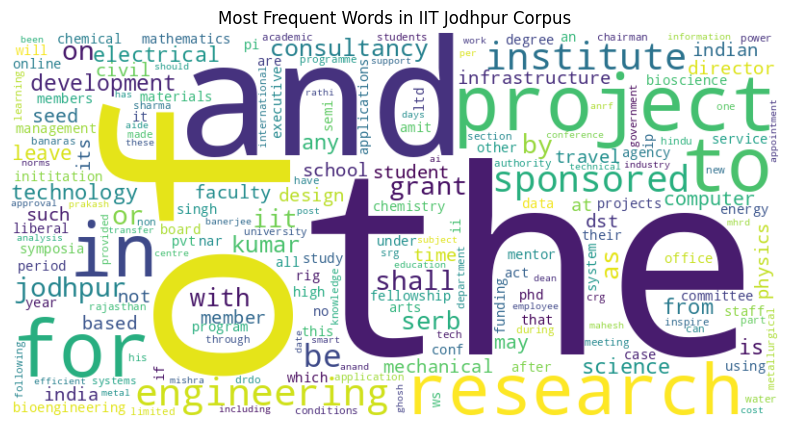


Word Cloud saved as 'iitj_wordcloud.png'

Successfully saved corpus to: /content/corpus.txt


In [5]:
!pip install PyMuPDF
import fitz  # PyMuPDF
import io
from urllib.parse import urljoin

# providing the desired links
def scrape_iitj_with_pdfs():
    target_urls = [
        "https://www.iitj.ac.in/", # Home and Announcements
        "https://www.iitj.ac.in/m/Index/main-departments?lg=en", # Departments
        "https://www.iitj.ac.in/office-of-academics/en/academic-programs", # Academic Programs
        "https://www.iitj.ac.in/office-of-research-development/en/office-of-research-and-development" ,# Research Pages,
        "https://www.iitj.ac.in/office-of-research-development/en/information" # Reserach info
    ]


    # Using a User-Agent header so the university server recognizes this as a standard browser request, rather than blocking it as an automated bot.
    headers = {'User-Agent': 'Mozilla/5.0'}
    full_corpus = ""

    for url in target_urls:
        print(f"--- Processing Page: {url} ---")
        try:
            response = requests.get(url, headers=headers, timeout=15)
            if response.status_code != 200: continue

            soup = BeautifulSoup(response.text, 'html.parser')

            # A. Extract Text from the HTML Page first
            for element in soup.find_all(['p', 'h1', 'h2', 'h3', 'h4', 'h5', 'h6', 'li']):
                full_corpus += element.get_text(strip=True) + " "

            # B. Find all PDF links
            pdf_links = []
            for link in soup.find_all('a', href=True):
                href = link['href']
                if href.lower().endswith('.pdf'):
                    # Convert relative URL to absolute URL
                    pdf_url = urljoin(url, href)
                    pdf_links.append(pdf_url)

            # C. Scrape each PDF found
            for pdf_url in set(pdf_links): # 'set' removes duplicates
                print(f"   -> Extracting PDF: {pdf_url.split('/')[-1]}")
                try:
                    pdf_response = requests.get(pdf_url, headers=headers, timeout=20)
                    # Open PDF from bytes
                    with fitz.open(stream=io.BytesIO(pdf_response.content), filetype="pdf") as doc:
                        pdf_text = ""
                        for page in doc:
                            pdf_text += page.get_text()
                        full_corpus += pdf_text + " "
                except Exception as e:
                    print(f"      Error reading PDF {pdf_url}: {e}")

                time.sleep(0.5)

        except Exception as e:
            print(f"Error scraping {url}: {e}")

    return full_corpus

# Execution

print("Starting web scraper...")
corpus_data = scrape_iitj_with_pdfs()

if corpus_data.strip():
    print(f"\nScraping complete. Total characters collected: {len(corpus_data)}")
    print("\nPreprocessing text...")
    clean_corpus_tokens = preprocess_text(corpus_data)
    print("\nPreprocessing complete. Generating stats...")
    generate_dataset_stats(clean_corpus_tokens)
    # Saving the cleaned corpus as text file
    clean_corpus_tokens_string = " ".join(clean_corpus_tokens)
    save_corpus_to_file(clean_corpus_tokens_string, "corpus.txt")

else:
    print("No text was scraped. Please check your internet connection or the target URLs.")

TASK-2: MODEL TRAINING

Train two Word2Vec models: Continuous Bag of Words (CBOW) and Skip-gram with Negative
Sampling. For each model, experiment with: (i) Embedding dimension, (ii) Context window
size and (iii) Number of negative samples. Show these results formally in the report.

In [6]:
# models from scratch

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

class Word2VecDataset(Dataset):
    def __init__(self, tokens, word_to_idx, window_size=2, mode='skipgram'):
        self.data = []
        self.mode = mode
        for i in range(window_size, len(tokens) - window_size):
            target = word_to_idx[tokens[i]]
            context = [word_to_idx[tokens[i-j]] for j in range(1, window_size+1)] + \
                      [word_to_idx[tokens[i+j]] for j in range(1, window_size+1)]

            if mode == 'skipgram':
                # Skip-gram: Each context word is a separate training example
                for ctx in context:
                    self.data.append((target, ctx))
            else:
                # CBOW: The entire context window predicts one target
                self.data.append((torch.tensor(context), target))

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return self.data[idx]

class CBOWModel(nn.Module):
    def __init__(self, vocab_size, embed_dim):
        super(CBOWModel, self).__init__()
        self.embeddings = nn.Embedding(vocab_size, embed_dim)
        self.output = nn.Linear(embed_dim, vocab_size)

    def forward(self, context_ids):
        # context_ids shape: [batch_size, window_size*2]
        embeds = self.embeddings(context_ids) # [batch_size, window_size*2, embed_dim]
        avg_embeds = torch.mean(embeds, dim=1) # Average the context
        return self.output(avg_embeds)


class SkipGramModel(nn.Module):
    def __init__(self, vocab_size, embed_dim):
        super(SkipGramModel, self).__init__()
        self.embeddings = nn.Embedding(vocab_size, embed_dim)
        self.output = nn.Linear(embed_dim, vocab_size)

    def forward(self, target_id):
        v = self.embeddings(target_id)
        return self.output(v)

def train_model(tokens, mode='skipgram', embed_dim=100, epochs=10):
    vocab = sorted(list(set(tokens)))
    word_to_idx = {word: i for i, word in enumerate(vocab)}
    idx_to_word = {i: word for i, word in enumerate(vocab)}

    dataset = Word2VecDataset(tokens, word_to_idx, mode=mode)
    dataloader = DataLoader(dataset, batch_size=512, shuffle=True)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = SkipGramModel(len(vocab), embed_dim) if mode == 'skipgram' else CBOWModel(len(vocab), embed_dim)
    model.to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.005)

    print(f"\nTraining {mode.upper()} from scratch...")
    for epoch in range(epochs):
        total_loss = 0
        for x, y in dataloader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            output = model(x)
            loss = criterion(output, y)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        if (epoch + 1) % 2 == 0:
            print(f"Epoch {epoch+1} | Loss: {total_loss/len(dataloader):.4f}")

    return model, word_to_idx, idx_to_word

# EXECUTION
scratch_sg_model, w2i, i2w = train_model(clean_corpus_tokens, mode='skipgram')
scratch_cbow_model, _, _ = train_model(clean_corpus_tokens, mode='cbow')



Training SKIPGRAM from scratch...
Epoch 2 | Loss: 5.3555
Epoch 4 | Loss: 4.8530
Epoch 6 | Loss: 4.6679
Epoch 8 | Loss: 4.5743
Epoch 10 | Loss: 4.5191

Training CBOW from scratch...
Epoch 2 | Loss: 4.2141
Epoch 4 | Loss: 2.4755
Epoch 6 | Loss: 1.6880
Epoch 8 | Loss: 1.2672
Epoch 10 | Loss: 1.0131


In [7]:
# using inbuilt model libraries
!pip install gensim
from gensim.models import Word2Vec

def find_best_models(sentences):
    # Experiment Parameters as per Task-2 requirements
    dimensions = [50, 100, 200]      # (i) Embedding dimension
    windows = [2, 5, 10]             # (ii) Context window size
    neg_samples = [5, 15]            # (iii) Number of negative samples

    # Storage for the best versions
    best_cbow = {'model': None, 'score': -1, 'params': None}
    best_sg = {'model': None, 'score': -1, 'params': None}

    # using a random 'Validation Pair' to score the models
    # A good IITJ model should recognize that 'phd' and 'research' are related
    val_word_1, val_word_2 = 'phd', 'research'

    for sg_val in [0, 1]: # 0 = CBOW, 1 = Skip-gram
        arch_name = "CBOW" if sg_val == 0 else "Skip-gram"
        print(f"Optimizing {arch_name}...")

        for dim in dimensions:
            for win in windows:
                for neg in neg_samples:
                    start = time.time()
                    model = Word2Vec(
                        sentences=sentences,
                        sg=sg_val,
                        vector_size=dim,
                        window=win,
                        negative=neg,
                        min_count=2,
                        workers=4
                    )
                    duration = time.time() - start

                    try:
                        # Calculate cosine similarity score for this specific config
                        current_score = model.wv.similarity(val_word_1, val_word_2)
                    except KeyError:
                        current_score = 0

                    # displaying scores
                    print(f"{arch_name:<12} | {dim:<5} | {win:<5} | {neg:<5} | {duration:<20} | {current_score:<8.4f}")

                    # Update Best CBOW
                    if sg_val == 0 and current_score > best_cbow['score']:
                        best_cbow.update({'model': model, 'score': current_score,
                                        'params': (dim, win, neg)})

                    # Update Best Skip-gram
                    if sg_val == 1 and current_score > best_sg['score']:
                        best_sg.update({'model': model, 'score': current_score,
                                       'params': (dim, win, neg)})

    return best_cbow, best_sg

# --- EXECUTION ---
# tokens are split into "sentences" for better window context
chunk_size = 20
sentences = [clean_corpus_tokens[i:i + chunk_size] for i in range(0, len(clean_corpus_tokens), chunk_size)]

print("\n ----Formal Reporting (Table) ---")
print(f"\n{'Architecture':<12} | {'Dim':<5} | {'Win':<5} | {'Neg':<5} | {'Time (s)':<20} | {'Cosine Scores':<8}")
print("-" * 70)
cbow_winner, sg_winner = find_best_models(sentences)

print(f"\nBEST CBOW: Dim={cbow_winner['params'][0]}, Win={cbow_winner['params'][1]}, Neg={cbow_winner['params'][2]} (Score: {cbow_winner['score']:.4f})")
print(f"BEST SKIP-GRAM: Dim={sg_winner['params'][0]}, Win={sg_winner['params'][1]}, Neg={sg_winner['params'][2]} (Score: {sg_winner['score']:.4f})")



   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 73.3 MB/s eta 0:00:00

 ----Formal Reporting (Table) ---

Architecture | Dim   | Win   | Neg   | Time (s)             | Cosine Scores
----------------------------------------------------------------------
Optimizing CBOW...
CBOW         | 50    | 2     | 5     | 1.2473561763763428   | 0.8675  
CBOW         | 50    | 2     | 15    | 3.144874095916748    | 0.7392  
CBOW         | 50    | 5     | 5     | 1.808525562286377    | 0.8881  
CBOW         | 50    | 5     | 15    | 2.897458553314209    | 0.7160  
CBOW         | 50    | 10    | 5     | 1.4710981845855713   | 0.8873  
CBOW         | 50    | 10    | 15    | 2.9893317222595215   | 0.7606  
CBOW         | 100   | 2     | 5     | 1.2113263607025146   | 0.8998  
CBOW         | 100   | 2     | 15    | 1.845984697341919    | 0.7766  
CBOW         | 100   | 5     | 5     | 1.1640806198120117   | 0.8885  
CBOW         | 100   | 5     | 15    | 3.2037131786346436   | 0.7490  
CBOW     

In [8]:
# models trained with best combination of parameters identified using the inbuilt libraries
# 1. CBOW Model
model_cbow = Word2Vec(sentences=sentences,
                        sg=0,
                        vector_size=100,
                        window=2,
                        negative=5,
                        min_count=2,
                        workers=4)

# 2. Skip-gram Model (sg=1)
model_sg = Word2Vec(sentences=sentences,
                        sg=1,
                        vector_size=200,
                        window=2,
                        negative=5,
                        min_count=2,
                        workers=4)

print("Models trained successfully.")

Models trained successfully.


TASK-3: SEMANTIC ANALYSIS


In [9]:
import torch.nn.functional as F

# cosine similarity function for inbuilt models
def analyze_word(word, model,model_name):
    print(f"\nTop 5 neighbors for '{word}' as per model {model_name}:")
    try:
        neighbors = model.wv.most_similar(word, topn=5)
        for w, score in neighbors:
            print(f"{w}: {score:.4f}")
    except KeyError:
        print(f"Word '{word}' not in vocabulary.")

# To Create Mappings
def create_vocab_mappings(tokens):
    """Creates the dictionaries needed to turn text into numbers."""
    vocab = sorted(list(set(tokens)))
    w2i = {word: i for i, word in enumerate(vocab)}
    i2w = {i: word for i, word in enumerate(vocab)}
    return w2i, i2w, len(vocab)

# Analysis for Scratch Models
def analyze_scratch(word, model,model_name, w2i, i2w, topn=5):
    """Manually calculates cosine similarity for PyTorch models."""
    print(f"\nTop 5 neighbors for '{word}' as per model {model_name}:")
    if word not in w2i:
        print(f"Word '{word}' not in vocabulary.")
        return

    model.eval() # Set to evaluation mode
    device = next(model.parameters()).device

    with torch.no_grad():
        # Get the vector for our target word
        target_idx = torch.tensor([w2i[word]]).to(device)
        target_vec = model.embeddings(target_idx) # [1, embed_dim]

        # Get all vectors in the embedding layer
        all_vecs = model.embeddings.weight # [vocab_size, embed_dim]

        # Calculate Cosine Similarity
        # F.cosine_similarity computes similarity between the target and every row in all_vecs
        sims = F.cosine_similarity(target_vec, all_vecs)

        # Get top indices
        scores, indices = torch.topk(sims, topn + 1)


        for i in range(1, len(indices)): # Start from 1 to skip the word itself
            neighbor_word = i2w[indices[i].item()]
            print(f" - {neighbor_word}: {scores[i].item():.4f}")

# Analogy for Scratch Models
def solve_analogy_scratch(w1, w2, w3, model, w2i, i2w):
    """Solves w1:w2 :: w3:? (e.g., ug:btech :: pg:?)"""
    if any(w not in w2i for w in [w1, w2, w3]):
        return "Missing words in vocab"

    model.eval()
    device = next(model.parameters()).device
    with torch.no_grad():
        v1 = model.embeddings(torch.tensor([w2i[w1]]).to(device))
        v2 = model.embeddings(torch.tensor([w2i[w2]]).to(device))
        v3 = model.embeddings(torch.tensor([w2i[w3]]).to(device))

        # The analogy math: target = btech - ug + pg
        target_vec = v2 - v1 + v3

        all_vecs = model.embeddings.weight
        sims = F.cosine_similarity(target_vec, all_vecs)

        _, indices = torch.topk(sims, 5)
        for idx in indices:
            word = i2w[idx.item()]
            if word not in [w1, w2, w3]: # Return the first word that isn't part of the question
                return word
    return "Analogy words not found in small corpus."



In [10]:
# --- EXECUTION ---

# Creating the mappings first
w2i, i2w, vocab_size = create_vocab_mappings(clean_corpus_tokens)

# Using your new analysis functions
target_words = ['research', 'student', 'phd', 'exam']

for word in target_words:
    # for inbuilt models
    analyze_word(word, model_cbow, "CBOW_Inbuilt")
    analyze_word(word, model_sg, "Skip-gram_Inbuilt")
    # for models from stractch
    analyze_scratch(word, scratch_sg_model, "Skip-gram_from_Scratch", w2i, i2w)
    analyze_scratch(word, scratch_cbow_model, "CBOW_from_Scratch", w2i, i2w)

# Analogy: UG : BTech :: PG : ?
# Formula: result = vector(BTech) - vector(UG) + vector(PG)
print("\n--- ANALOGY EXPERIMENT ---")
print("\nUG is to BTech as PG is to...(as per Skip-gram_Inbuilt)")
try:
    result = model_sg.wv.most_similar(positive=['btech', 'pg'], negative=['ug'], topn=1)
    print(f"Result: {result[0][0]}")
except Exception as e:
    print("Analogy words not found in small corpus.")

print("\nUG is to BTech as PG is to...(as per CBOW_Inbuilt)")
try:
    result = model_cbow.wv.most_similar(positive=['btech', 'pg'], negative=['ug'], topn=1)
    print(f"UG : BTech :: PG : {result[0][0]}")
except Exception as e:
    print("Analogy words not found in small corpus.")

print("\nUG is to BTech as PG is to...(as per CBOW_from_Scratch)")
result = solve_analogy_scratch('ug', 'btech', 'pg', scratch_cbow_model, w2i, i2w)
print(f"UG : BTech :: PG : {result}")

print("\nUG is to BTech as PG is to...(as per Skip-gram_from_Scratch)")
result = solve_analogy_scratch('ug', 'btech', 'pg', scratch_sg_model, w2i, i2w)
print(f"UG : BTech :: PG : {result}")


Top 5 neighbors for 'research' as per model CBOW_Inbuilt:
project: 0.9836
crg: 0.9821
ambesh: 0.9816
rakshak: 0.9812
serb: 0.9785

Top 5 neighbors for 'research' as per model Skip-gram_Inbuilt:
drdo: 0.9117
msme: 0.9000
applications: 0.8997
brns: 0.8987
isro: 0.8909

Top 5 neighbors for 'research' as per model Skip-gram_from_Scratch:
 - mme: 0.3856
 - seed: 0.3766
 - iusstf: 0.3654
 - sponsored: 0.3544
 - measurement: 0.3464

Top 5 neighbors for 'research' as per model CBOW_from_Scratch:
 - organornetallic: 0.3563
 - seed: 0.3535
 - academia: 0.3314
 - careers: 0.3117
 - men: 0.3078

Top 5 neighbors for 'student' as per model CBOW_Inbuilt:
its: 0.9822
fellowship: 0.9814
inspire: 0.9757
phd: 0.9750
sire: 0.9658

Top 5 neighbors for 'student' as per model Skip-gram_Inbuilt:
phd: 0.9548
fellowship: 0.9544
inspire: 0.9352
scheme: 0.9197
visvesvaraya: 0.9168

Top 5 neighbors for 'student' as per model Skip-gram_from_Scratch:
 - mentor: 0.5020
 - mahfooz: 0.4136
 - panel: 0.3901
 - phd: 0.3

TASK-4: VISUALIZATION


Visualizing Scratch Skip-gram Clusters...


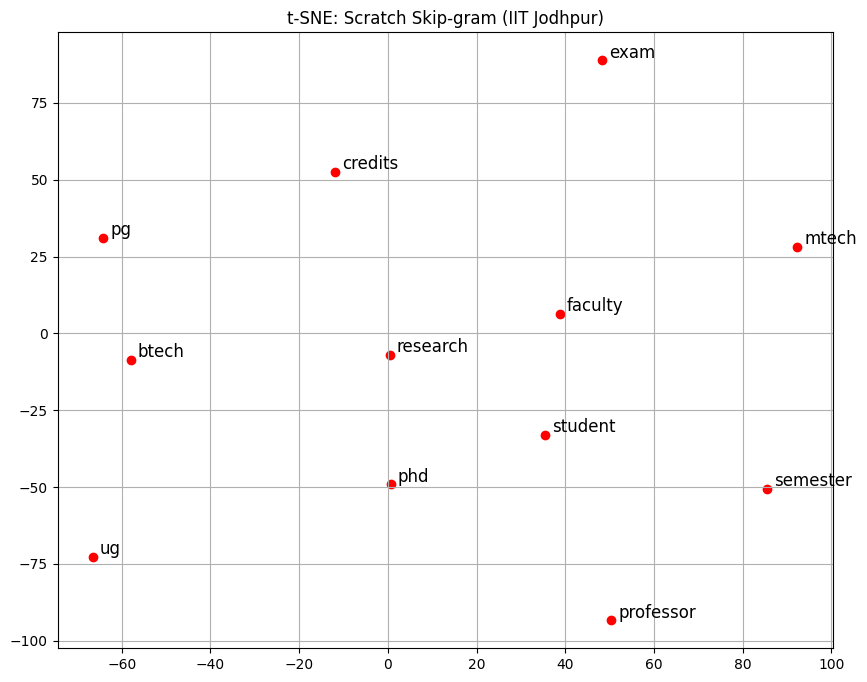

Visualizing Scratch CBOW Clusters...


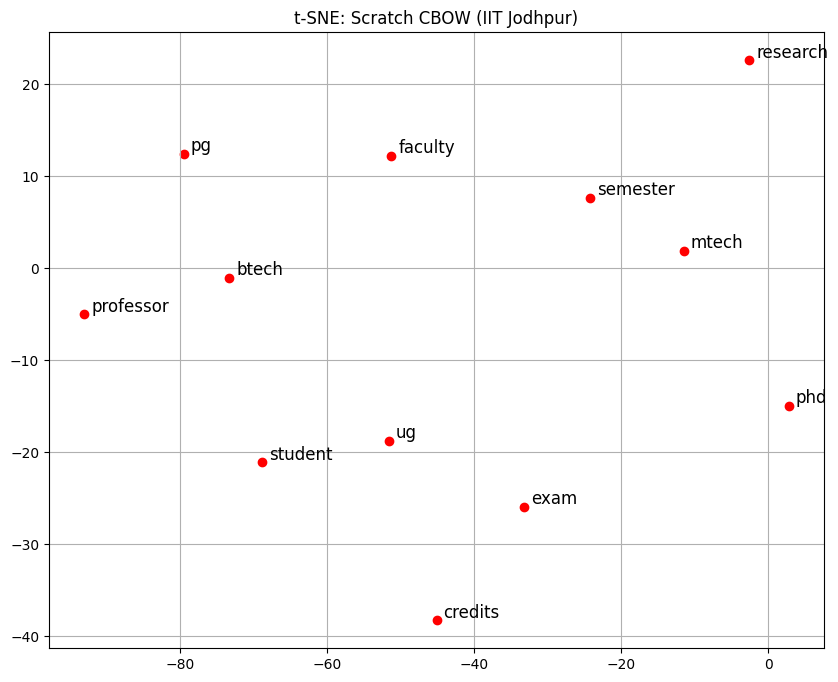

Visualizing Inbuilt Skip-gram Clusters...


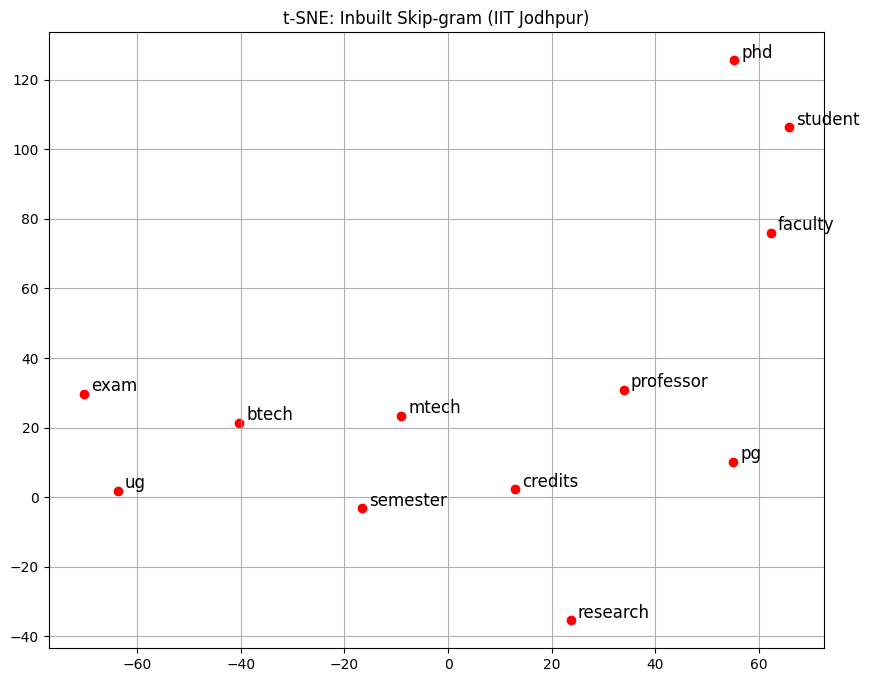

Visualizing Inbuilt CBOW Clusters...


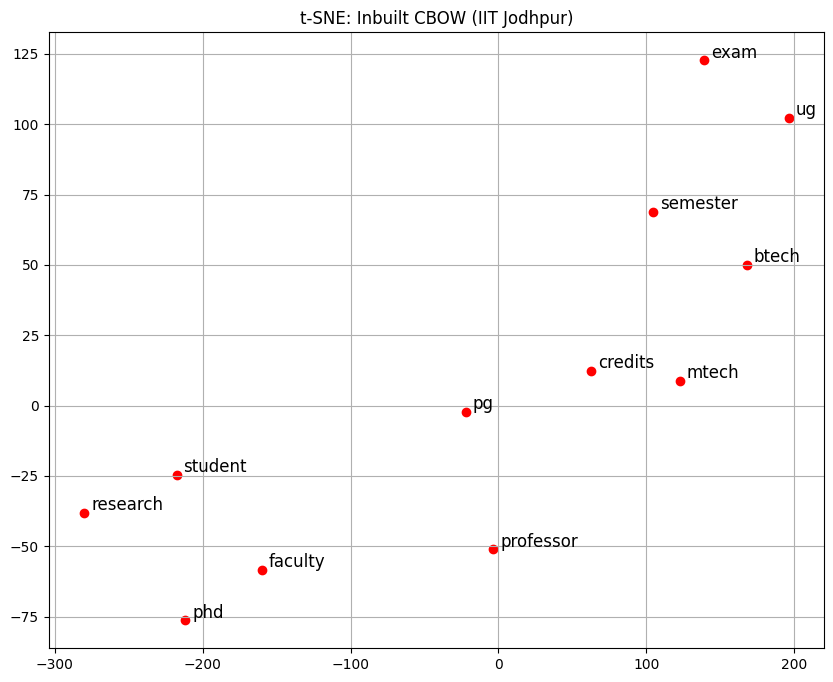

In [11]:
from sklearn.manifold import TSNE

def visualize_embeddings(model, w2i, selected_words, title="Word Embedding Clusters"):
    """
    Projects high-dimensional embeddings into 2D using t-SNE.
    """

    # 1. Extract vectors for the selected words
    vectors = []
    valid_words = []

    # Check if the model is a PyTorch model (Scratch)
    is_pytorch = isinstance(model, torch.nn.Module)

    for word in selected_words:
        try:
            if is_pytorch:
                # Logic for Scratch PyTorch models
                if word in w2i:
                    model.eval()
                    device = next(model.parameters()).device
                    idx = torch.tensor([w2i[word]]).to(device)
                    with torch.no_grad():
                        vec = model.embeddings(idx).cpu().numpy().flatten()
                    vectors.append(vec)
                    valid_words.append(word)
            else:
                # Logic for Inbuilt Gensim models
                if word in model.wv:
                    vectors.append(model.wv[word])
                    valid_words.append(word)
        except Exception as e:
            continue


    if len(vectors) < 2:
        print(f"Not enough words found in {title} to visualize.")
        return

    if not vectors:
        print("None of the selected words were found in the vocabulary.")
        return

    vectors = np.array(vectors)

    # 2. Run t-SNE
    # Perplexity should be smaller than the number of points
    tsne = TSNE(n_components=2, random_state=42, perplexity=min(5, len(valid_words)-1), init='pca', learning_rate='auto')
    low_dim_embeds = tsne.fit_transform(vectors)

    # 3. Plotting
    plt.figure(figsize=(10, 8))
    for i, word in enumerate(valid_words):
        x, y = low_dim_embeds[i, :]
        plt.scatter(x, y, marker='o', color='red')
        plt.annotate(word, (x, y), xytext=(5, 2), textcoords='offset points', fontsize=12)

    plt.title(title)
    plt.grid(True)
    plt.show()

# --- EXECUTION ---
# Group words into logical clusters to see if the model groups them
academic_cluster = ['btech', 'mtech', 'phd', 'ug', 'pg', 'student', 'professor', 'faculty', 'research', 'exam', 'semester', 'credits']

print("Visualizing Scratch Skip-gram Clusters...")
# using w2i from previous cell
visualize_embeddings(scratch_sg_model, w2i, academic_cluster, title="t-SNE: Scratch Skip-gram (IIT Jodhpur)")

print("Visualizing Scratch CBOW Clusters...")
visualize_embeddings(scratch_cbow_model, w2i, academic_cluster, title="t-SNE: Scratch CBOW (IIT Jodhpur)")

print("Visualizing Inbuilt Skip-gram Clusters...")
visualize_embeddings(model_sg, w2i, academic_cluster, title="t-SNE: Inbuilt Skip-gram (IIT Jodhpur)")

print("Visualizing Inbuilt CBOW Clusters...")
visualize_embeddings(model_cbow, w2i, academic_cluster, title="t-SNE: Inbuilt CBOW (IIT Jodhpur)")

In [12]:
import random
# using a random list of words for vizualization from courpus
# Converting the corpus into a list of unique words (Vocabulary)
unique_vocab = list(set(clean_corpus_tokens))

# Ensure we don't try to sample more than what exists
# selecting random 40 words
sample_size = min(40, len(unique_vocab))
random_40_words = random.sample(unique_vocab, sample_size)
random_40_words

['alzheimer',
 'connected',
 'lycorane',
 'was',
 'acl',
 'clients',
 'kursi',
 'am',
 'mitanshu',
 'biological',
 'freestanding',
 'facets',
 'moni',
 'tata',
 'exchangers',
 'transitions',
 'inflammasome',
 'difficulties',
 'framme',
 'interharmonics',
 'fronthaul',
 'transistor',
 'tr',
 'dichroism',
 'forensics',
 'dip',
 'mexico',
 'universily',
 'capable',
 'arpes',
 'larger',
 'initial',
 'surojit',
 'educational',
 'samanta',
 'aspect',
 'heckathon',
 'contained',
 'chandramouli',
 'compounds']

Visualizing Scratch Skip-gram Clusters...


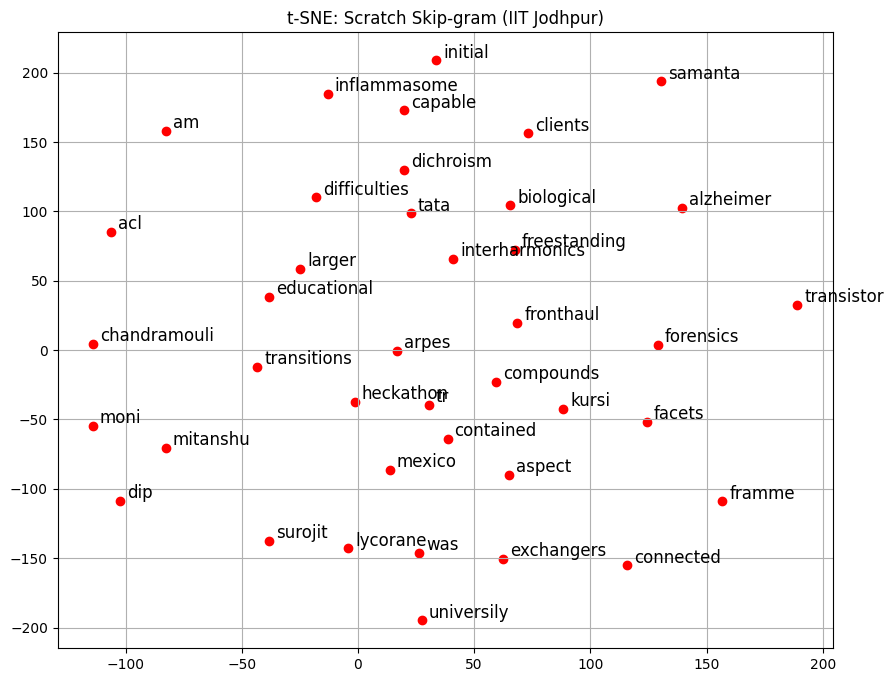

Visualizing Scratch CBOW Clusters...


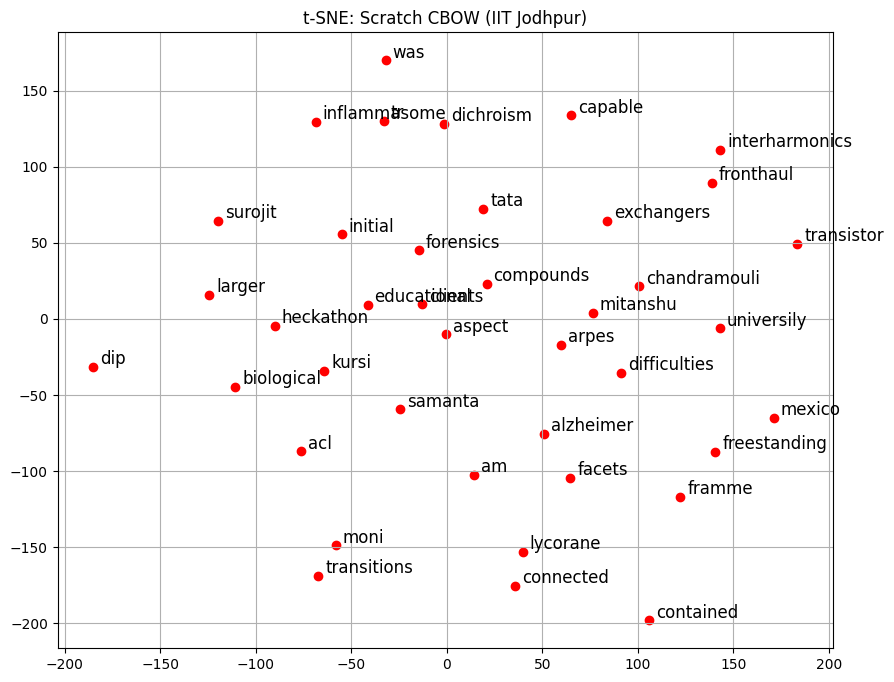

Visualizing Inbuilt Skip-gram Clusters...


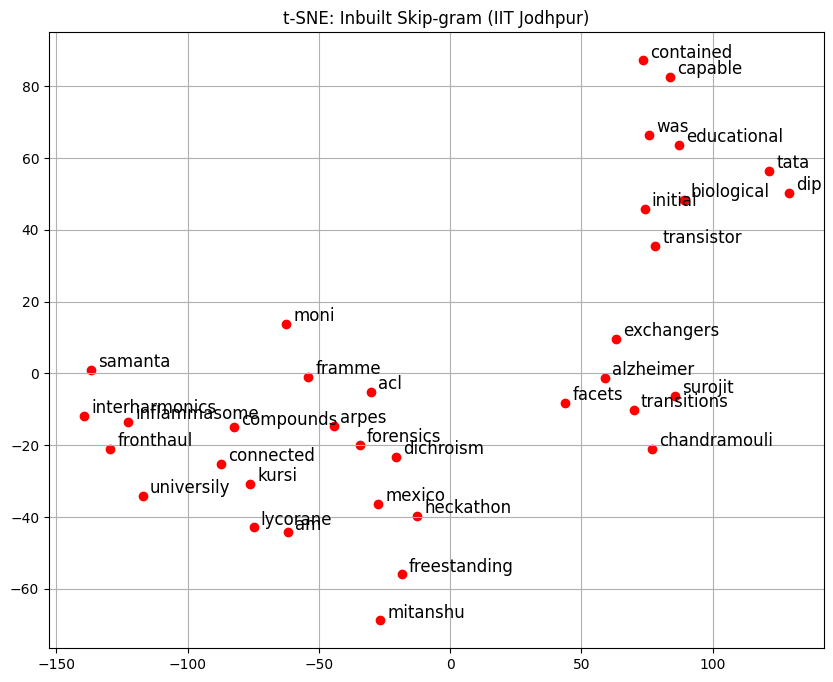

Visualizing Inbuilt CBOW Clusters...


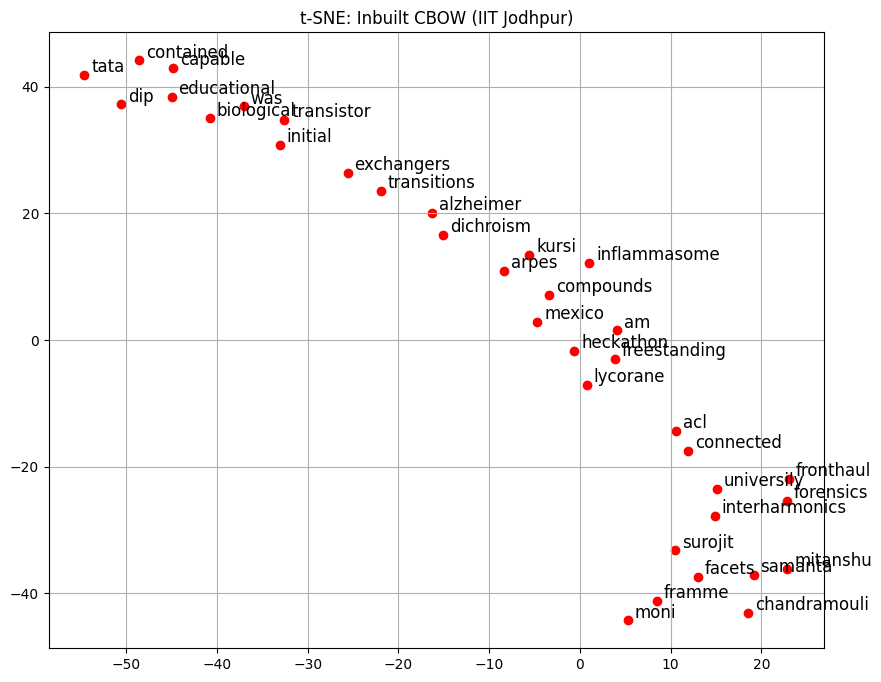

In [13]:
print("Visualizing Scratch Skip-gram Clusters...")
# using w2i from previous cell
visualize_embeddings(scratch_sg_model, w2i, random_40_words, title="t-SNE: Scratch Skip-gram (IIT Jodhpur)")

print("Visualizing Scratch CBOW Clusters...")
visualize_embeddings(scratch_cbow_model, w2i, random_40_words, title="t-SNE: Scratch CBOW (IIT Jodhpur)")

print("Visualizing Inbuilt Skip-gram Clusters...")
visualize_embeddings(model_sg, w2i, random_40_words, title="t-SNE: Inbuilt Skip-gram (IIT Jodhpur)")

print("Visualizing Inbuilt CBOW Clusters...")
visualize_embeddings(model_cbow, w2i, random_40_words, title="t-SNE: Inbuilt CBOW (IIT Jodhpur)")

QUESTION FROM GOOGLE FORM :
P1: Take one word from your learned vocabulary, for example  if you take “Jodhpur”, and print its full 300-dimensional embedding vector from your trained word2vec model on the IITJ corpus, as a comma-separated list. (Note: you should take a word of your choice other than Jodhpur). So the expected format is something like:

Jodhpur - 0.1284, -0.0921, 0.4410, ..., 0.0037

In [14]:
# a prominent word from the IITJ corpus (other than Jodhpur)
target_word = "research"

# Check if the word exists in the  model's vocabulary
if target_word in model_cbow.wv:
    # Extract the full embedding vector (300 dimensions)
    vector = model_cbow.wv[target_word]

    # Format the vector values to 4 decimal places and join with commas
    formatted_vector = ", ".join([f"{val:.4f}" for val in vector])

    # Print in the exact requested format
    print(f"{target_word} - {formatted_vector}")
else:
    print(f"The word '{target_word}' is not in the model's vocabulary.")

research - 0.2530, 0.5164, 0.7433, 0.6086, 0.5216, -0.6474, 0.3840, 0.9896, -0.9679, -1.1961, 0.0638, -1.2624, 0.7370, 0.3101, 0.5607, 0.7155, 1.0757, -0.6350, -0.6566, -0.9959, 0.4425, 0.4439, 1.2073, -0.9382, -0.8409, 0.6494, -0.3253, -0.3558, -0.0759, 0.8623, 0.8070, -0.2457, 0.5179, -1.0829, -0.4664, 0.2151, -0.0162, -0.7028, -0.7837, -0.3080, 0.7195, -0.0591, 0.1142, 0.9026, 0.4194, 0.0721, -1.3711, -0.7759, 0.5830, 0.6216, -0.5372, -0.7299, -0.8381, -1.0555, -0.2619, 0.7449, 0.1499, 0.3717, -0.3638, -0.1042, 0.0880, 0.0498, 0.2374, 0.8768, -0.9764, 1.1067, 0.0344, 0.4912, -0.3462, 0.2970, -0.3003, -0.0125, 1.1789, 0.4091, 0.3137, 0.1124, 1.1810, 0.7166, -1.1230, -0.6821, -0.8639, -0.0346, -0.2592, 0.8449, -0.2331, -0.3966, 0.8913, 1.0840, 1.1377, -0.5593, 0.9467, -0.1889, -0.9524, 0.9347, 0.7129, 0.8809, 0.4677, -1.0474, 0.4227, -0.8138


In [15]:
from collections import Counter

word_counts = Counter(clean_corpus_tokens)

# the top 10 most common words (returns a list of tuples: [(word, freq), ...])
top_10_words = word_counts.most_common(10)

# Format the output exactly as requested: word1, freq1, word2, freq2, ...
formatted_output = ", ".join([f"{word}, {freq}" for word, freq in top_10_words])


print(formatted_output)

the, 4631, of, 4326, and, 2519, project, 1539, for, 1523, to, 1452, in, 1427, research, 1274, engineering, 1260, institute, 1182
